## Basic usage 

**The tutorial including:**
- Generating detector response in the frequency domain;
- Generating detector response in the wavelet domain;

In [1]:
import sys 
sys.path.append('/home/hydrogen/workspace/Space_GW/pespace')
sys.path.append('/home/hydrogen/workspace/Space_GW/tiwave')

import taichi as ti
ti.init(arch=ti.cpu, default_fp=ti.f64)
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline


duration = 31536000    # 1 year observation
cadance = 10
TDI_chans = ("A", "E", "T")
TDI_gen = '1.5'
parameters = dict(
    total_mass = 3089053.9,
    mass_ratio = 0.11,
    chi_1 = 0.3986046314480332,
    chi_2 = 0.5465882372512956,
    luminosity_distance = 6000.42017466175677,
    inclination = 0.30782038099413395,
    reference_phase = 0.0,
    coalescence_time = 0.0,
    ecliptic_latitude = -0.5256036732051035,
    ecliptic_longitude = 1.1637,
    polarization = 1.30782038099413395,
)



[Taichi] version 1.6.0, llvm 15.0.4, commit f1c6fbbd, linux, python 3.10.12


[I 07/31/24 18:07:13.247 2057080] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=x64


In [2]:
from pespace.detectors import TDIChannelsData, SpaceborneInterferometer
from pespace.noise import noise_models
from pespace.likelihood import FrequencyDomainLikelihood
from tiwave.waveforms import IMRPhenomD


mbhb = TDIChannelsData(label="injection_individual_MBHB")
mbhb.set_frequency_domain_data_with_zero_value(channels=TDI_chans, generation=TDI_gen, duration=duration, cadence=cadance)
mbhb.set_frequency_domain_noise_power_density_from_analystic_model(noise_models['LISA_SciRDv1'])
noise_realization = mbhb.generate_realization_from_frequency_domain_noise_power_density()
mbhb.add_into_frequency_domian_data(noise_realization)
lisa = SpaceborneInterferometer(name='LISA', TDI_data=mbhb)
lisa.initialize_response_container_in_frequency_domain()

wf = IMRPhenomD(lisa.TDI_data.frequency_samples)
wf.update_waveform(parameters)
lisa.inject_frequency_domain_signal(wf.waveform_container, parameters['ecliptic_longitude'], parameters['ecliptic_latitude'], parameters['polarization'])

likelihood = FrequencyDomainLikelihood(wf, lisa)
likelihood.parameters.update(parameters)
%timeit likelihood.log_likelihood()


/home/hydrogen/workspace/Space_GW/pespace/pespace/utils.py:7: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


`parameter_sanity_check` is disable, make sure all parameters passed in are valid.
`waveform_container` is not given, initializing one with returned_form=polarizations, include_tf=True
39.4 ms ± 2.16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


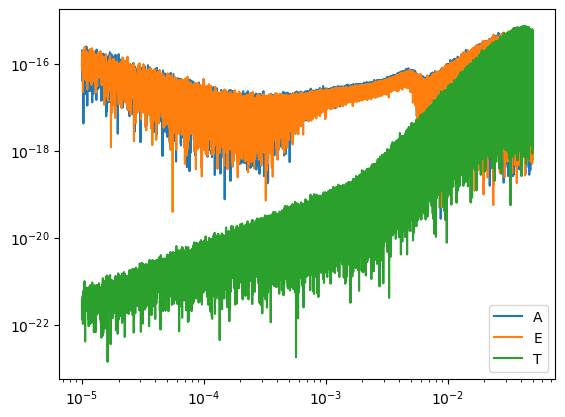

In [3]:
TDI_data_array = lisa.TDI_data.frequency_domain_TDI_data.to_numpy()
plt.figure()
for chan in TDI_chans:
    plt.loglog(lisa.TDI_data.frequency_samples_numpy_array, np.abs(TDI_data_array[chan][:,0]+1j*TDI_data_array[chan][:,1]), label=chan)
plt.legend()